# Dataset Prep — AI vs Real Face Detector
Run this notebook **on Colab** (GPU runtime not required for this notebook — this only downloads/organizes data; training happens in `train_colab.ipynb`).

**Phase 1:** FFHQ (real) vs StyleGAN2 (fake) — validates the pipeline.
**Phase 2:** adds diffusion-generated faces as a second fake source, kept in a separate subfolder so it's a drop-in, not a rewrite.

Output structure this notebook builds:
```
data/
├── real/                  # FFHQ subset
└── fake/
    ├── stylegan2/          # Phase 1
    └── diffusion/          # Phase 2 (added later)
```


## 1. Mount Google Drive (for persistent storage across sessions)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/ai-vs-real-face-detector'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(os.path.join(DATA_DIR, 'real'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'fake', 'stylegan2'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'fake', 'diffusion'), exist_ok=True)
print("Data will persist at:", DATA_DIR)


Mounted at /content/drive
Data will persist at: /content/drive/MyDrive/ai-vs-real-face-detector/data


## 2. Kaggle API setup
You need a Kaggle account + API token.
1. Go to kaggle.com → your profile → Account → **Create New API Token** (downloads `kaggle.json`)
2. Upload it below when prompted.


In [ ]:
from google.colab import files
import os

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Upload your kaggle.json:")
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    for fn in uploaded:
        os.rename(fn, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle


Upload your kaggle.json:


Saving kaggle.json to kaggle.json


## 3. Phase 1 — Download real faces (FFHQ subset)
Using `pankymathur/ffhq-224k` (FFHQ resized to 224x224 — much smaller than full-res FFHQ, and 224x224 is what the deep branch resizes to anyway, so no quality lost for this use case).

We only keep the first `N_REAL` images rather than the full 70k — plenty for fine-tuning, and keeps disk/session time manageable.


In [ ]:
N_REAL = 5000  # adjust if you want more/fewer

!kaggle datasets download -d pankymathur/ffhq-224k -p /content/ffhq_dl --unzip

import glob, shutil

src_files = sorted(glob.glob('/content/ffhq_dl/**/*.png', recursive=True) +
                    glob.glob('/content/ffhq_dl/**/*.jpg', recursive=True))
print(f"Found {len(src_files)} FFHQ images, keeping first {N_REAL}")

for f in src_files[:N_REAL]:
    shutil.copy(f, os.path.join(DATA_DIR, 'real', os.path.basename(f)))

print("Real faces saved:", len(os.listdir(os.path.join(DATA_DIR, 'real'))))


Dataset URL: https://www.kaggle.com/datasets/pankymathur/ffhq-224k
License(s): CC-BY-NC-SA-4.0
100% 3.00G/3.00G [03:03<00:00, 17.5MB/s]

Found 51160 FFHQ images, keeping first 5000
Real faces saved: 5000


## 4. Phase 1 — Download StyleGAN2 fake faces
Using `hyperclaw79/fakefaces` (~6.4k StyleGAN2-generated faces from thispersondoesnotexist.com). This dataset is smaller than FFHQ, so we take all of it (or cap with `N_FAKE` to match your real count for class balance).


In [ ]:
N_FAKE = 5000  # match N_REAL for class balance

!kaggle datasets download -d hyperclaw79/fakefaces -p /content/fake_dl --unzip

fake_files = sorted(glob.glob('/content/fake_dl/**/*.png', recursive=True) +
                     glob.glob('/content/fake_dl/**/*.jpg', recursive=True))
print(f"Found {len(fake_files)} StyleGAN2 fake images, keeping first {N_FAKE}")

for f in fake_files[:N_FAKE]:
    shutil.copy(f, os.path.join(DATA_DIR, 'fake', 'stylegan2', os.path.basename(f)))

print("StyleGAN2 fakes saved:", len(os.listdir(os.path.join(DATA_DIR, 'fake', 'stylegan2'))))


Dataset URL: https://www.kaggle.com/datasets/hyperclaw79/fakefaces
License(s): CC0-1.0
100% 5.33G/5.33G [06:44<00:00, 14.1MB/s]

Found 6400 StyleGAN2 fake images, keeping first 5000
StyleGAN2 fakes saved: 5000


## 5. Sanity check — counts and sample preview
Always look at actual images before training on them — confirms downloads aren't corrupted and faces are actually visible (needed for the physics branch to work at all).


Real: 5000 | Fake (StyleGAN2): 5000


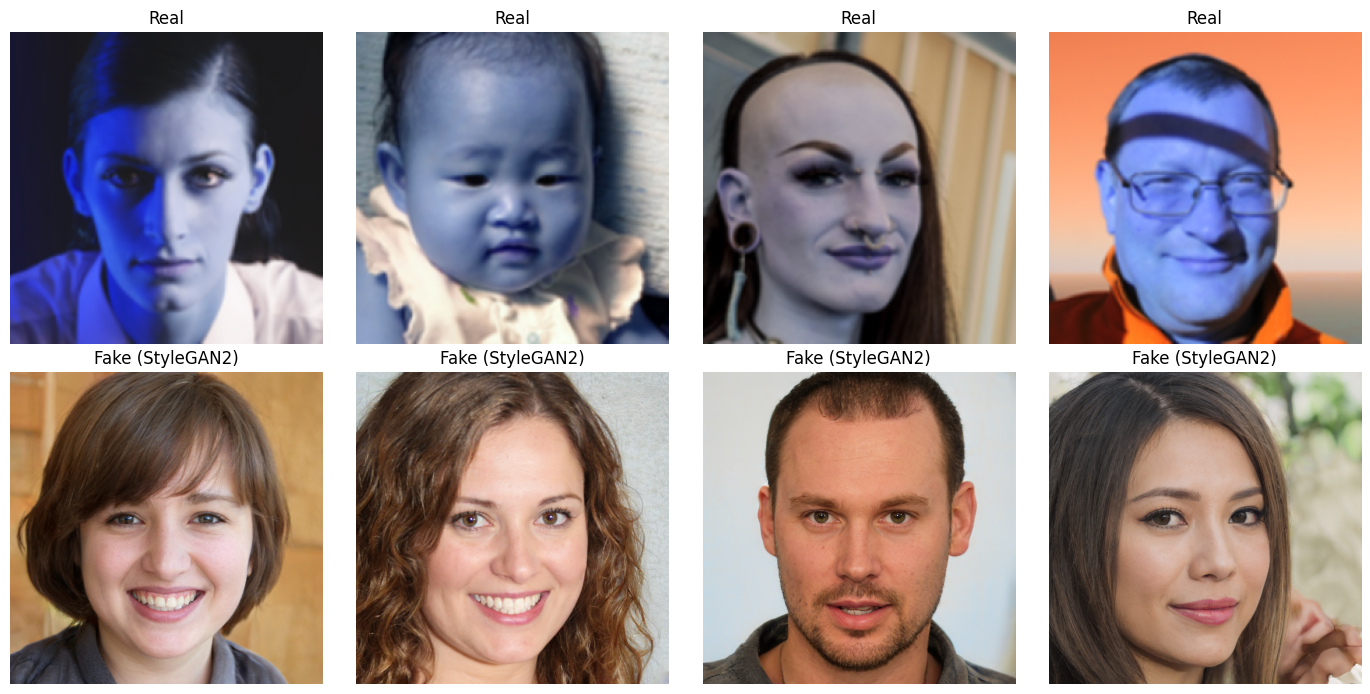

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

real_files = os.listdir(os.path.join(DATA_DIR, 'real'))
fake_files = os.listdir(os.path.join(DATA_DIR, 'fake', 'stylegan2'))
print(f"Real: {len(real_files)} | Fake (StyleGAN2): {len(fake_files)}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    img = Image.open(os.path.join(DATA_DIR, 'real', real_files[i]))
    axes[0, i].imshow(img); axes[0, i].axis('off'); axes[0, i].set_title('Real')
for i in range(4):
    img = Image.open(os.path.join(DATA_DIR, 'fake', 'stylegan2', fake_files[i]))
    axes[1, i].imshow(img); axes[1, i].axis('off'); axes[1, i].set_title('Fake (StyleGAN2)')
plt.tight_layout()
plt.show()


## 6. Train/val/test split
Creates split manifests (CSV) rather than moving files, so both `stylegan2/` and `diffusion/` subfolders stay intact and Phase 2 additions don't require re-splitting from scratch.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

rows = []
for f in os.listdir(os.path.join(DATA_DIR, 'real')):
    rows.append({'path': os.path.join('real', f), 'label': 0, 'source': 'ffhq'})
for f in os.listdir(os.path.join(DATA_DIR, 'fake', 'stylegan2')):
    rows.append({'path': os.path.join('fake', 'stylegan2', f), 'label': 1, 'source': 'stylegan2'})

df = pd.DataFrame(rows)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

os.makedirs(os.path.join(DATA_DIR, 'splits'), exist_ok=True)
train_df.to_csv(os.path.join(DATA_DIR, 'splits', 'train.csv'), index=False)
val_df.to_csv(os.path.join(DATA_DIR, 'splits', 'val.csv'), index=False)
test_df.to_csv(os.path.join(DATA_DIR, 'splits', 'test.csv'), index=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(train_df['source'].value_counts())


Train: 7000 | Val: 1500 | Test: 1500
source
stylegan2    3500
ffhq         3500
Name: count, dtype: int64


---
## Phase 2 (run later, after Phase 1 pipeline is validated) — add diffusion-generated faces

Uses `Purdue-M2/AI-Face-FairnessBench` (Hugging Face) for diffusion-model faces (Stable Diffusion, DALL·E 2, Midjourney, etc.) — keeps generator diversity so the model doesn't just learn "detect StyleGAN artifacts."

**Don't run this yet.** Come back once you've confirmed Phase 1 trains and the physics branch shows a real signal on FFHQ vs StyleGAN2.


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

rows = []

# ============================================================
# REAL IMAGES
# ============================================================

real_dir = os.path.join(DATA_DIR, "real")

for f in os.listdir(real_dir):
    path = os.path.join(real_dir, f)

    if os.path.isfile(path):
        rows.append({
            "path": os.path.join("real", f),
            "label": 0,
            "source": "real"
        })


# ============================================================
# FAKE — STYLEGAN2
# ============================================================

stylegan_dir = os.path.join(
    DATA_DIR,
    "fake",
    "stylegan2"
)

if os.path.isdir(stylegan_dir):

    for f in os.listdir(stylegan_dir):
        path = os.path.join(stylegan_dir, f)

        if os.path.isfile(path):
            rows.append({
                "path": os.path.join(
                    "fake",
                    "stylegan2",
                    f
                ),
                "label": 1,
                "source": "stylegan2"
            })


# ============================================================
# FAKE — DIFFUSION
# ============================================================

diffusion_dir = os.path.join(
    DATA_DIR,
    "fake",
    "diffusion"
)

if os.path.isdir(diffusion_dir):

    for f in os.listdir(diffusion_dir):
        path = os.path.join(diffusion_dir, f)

        if os.path.isfile(path):
            rows.append({
                "path": os.path.join(
                    "fake",
                    "diffusion",
                    f
                ),
                "label": 1,
                "source": "diffusion"
            })


# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(rows)

print("Total images:", len(df))

print("\nOverall composition:")
print(
    df.groupby(
        ["label", "source"]
    ).size()
)


# ============================================================
# STRATIFICATION
# ============================================================

# Preserve BOTH label and source during splitting.
#
# Examples:
#   0_real
#   1_stylegan2
#   1_diffusion

strat_key = (
    df["label"].astype(str)
    + "_"
    + df["source"]
)


# ============================================================
# 70% TRAIN / 15% VALIDATION / 15% TEST
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=strat_key,
    random_state=42
)

temp_strat_key = (
    temp_df["label"].astype(str)
    + "_"
    + temp_df["source"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_strat_key,
    random_state=42
)


# ============================================================
# SAVE SPLITS
# ============================================================

split_dir = os.path.join(
    DATA_DIR,
    "splits"
)

os.makedirs(
    split_dir,
    exist_ok=True
)

train_df.to_csv(
    os.path.join(split_dir, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(split_dir, "val.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(split_dir, "test.csv"),
    index=False
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print(
    f"\nTrain: {len(train_df)}"
    f" | Val: {len(val_df)}"
    f" | Test: {len(test_df)}"
)

print("\nTrain composition:")
print(
    train_df.groupby(
        ["label", "source"]
    ).size()
)

print("\nValidation composition:")
print(
    val_df.groupby(
        ["label", "source"]
    ).size()
)

print("\nTest composition:")
print(
    test_df.groupby(
        ["label", "source"]
    ).size()
)

Total images: 8312

Overall composition:
label  source   
0      real         5000
1      stylegan2    3312
dtype: int64

Train: 5818 | Val: 1247 | Test: 1247

Train composition:
label  source   
0      real         3500
1      stylegan2    2318
dtype: int64

Validation composition:
label  source   
0      real         750
1      stylegan2    497
dtype: int64

Test composition:
label  source   
0      real         750
1      stylegan2    497
dtype: int64


## Next step
Once `data/splits/train.csv` etc. exist and the sample preview looks correct, open `train_colab.ipynb` and point it at this same `DATA_DIR` for Stage 1 training.
